In [6]:
import pandas as pd

data = {
    'job_skills': ['python', 'sql', 'java', 'c++', 'javascript', 'html', 'css', 'php', 'ruby', 'excel'],  # ✅ added 'excel'
    'skills_count': [30, 25, 28, 15, 18, 5, 4, 3, 2, 1],   # 10 values ✅
    'skill_pay': [100, 98, 80, 70, 60, 50, 40, 30, 20, 10]  # 10 values ✅
}

df = pd.DataFrame(data)
df

,job_skills,skills_count,skill_pay
0,python,30,100
1,sql,25,98
2,java,28,80
3,c++,15,70
4,javascript,18,60
5,html,5,50
6,css,4,40
7,php,3,30
8,ruby,2,20
9,excel,1,10


<Axes: xlabel='skills_count', ylabel='skill_pay'>

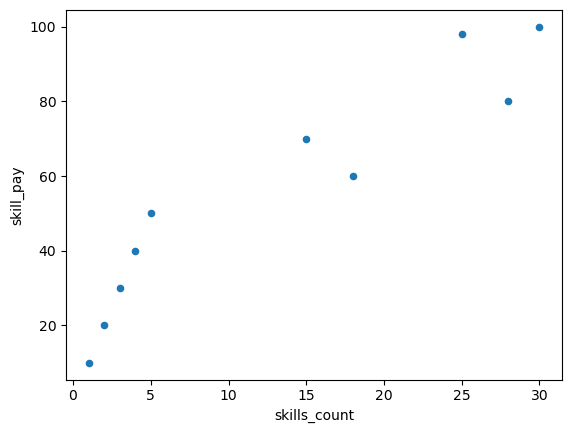

In [7]:
data = {
    'job_skills': ['python', 'sql', 'java', 'c++', 'javascript', 'html', 'css', 'php', 'ruby', 'excel'],  # ✅ added 'excel'
    'skills_count': [30, 25, 28, 15, 18, 5, 4, 3, 2, 1],   # 10 values ✅
    'skill_pay': [100, 98, 80, 70, 60, 50, 40, 30, 20, 10]  # 10 values ✅
}

df = pd.DataFrame(data)

df.plot(kind= 'scatter', x='skills_count', y='skill_pay')

In [8]:
# Importing Libraries
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

c:\Users\HomePC\.conda\envs\python_course\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
df_DE = df[df['job_title_short'] == 'Data Engineer']


In [10]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count =('job_skills','count'),
    median_salary =('salary_year_avg', 'median')
)

skill_stats = skill_stats.sort_values(by= 'skill_count', ascending=False).head(10)

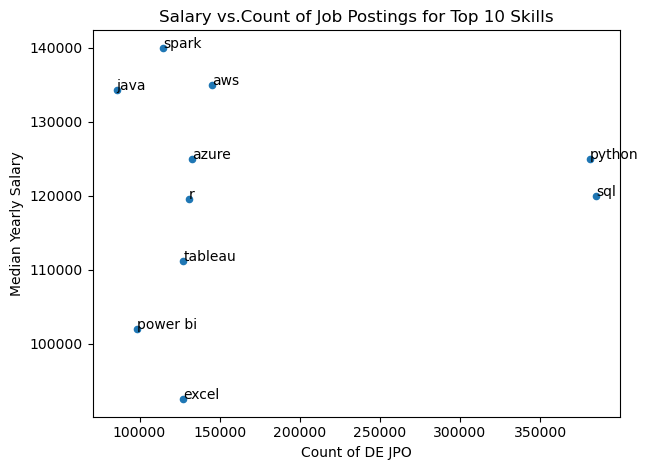

In [11]:
skill_stats.plot(kind='scatter', x= 'skill_count', y='median_salary')
plt.xlabel('Count of DE JPO')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs.Count of Job Postings for Top 10 Skills')
plt.tight_layout()

for i, txt in enumerate(skill_stats.index):
    plt.text(skill_stats['skill_count'].iloc[i],skill_stats['median_salary'].iloc[i], txt)
plt.show()